# 01c — One-patient walk-through (April per-patient × band)

Mirror of `01b_single_network_walkthrough` applied to **one subject ×
one band**. The $2 \times 5$ grid shows CO2 (top row) vs rest (bottom
row) across the five processing variants for the selected pair.

Change `SUBJECT` / `BAND` in §2 to swap the cohort element.

In [1]:
from __future__ import annotations

from pathlib import Path

import networkx as nx
import numpy as np

from multifunbrain.datasets.april import (
    DEFAULT_APRIL_ROOT,
    discover_april,
    gamma_for,
    label_for,
    load_entry,
)
from multifunbrain.preprocessing import (
    marchenko_pastur_denoise,
    prepare_correlation_matrix,
)
from multifunbrain.visualization.plotlib import (
    plot_correlation_matrix,
    plot_percolation_curve,
    plot_weight_distribution,
    plt,
)

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT.name and not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
APRIL_ROOT = REPO_ROOT / DEFAULT_APRIL_ROOT
GRID = (2, 5)  # rows = contrasts (co2, rest); cols = processing variants

print(f"repo:    {REPO_ROOT}")
print(f"data:    {APRIL_ROOT}")

repo:    /home/opisthofulax/Documents/research+/brain_network/multifun-brain
data:    /home/opisthofulax/Documents/research+/brain_network/multifun-brain/data/correlation_mat_april_data


## 1. Discover the patient cohort

Each (subject, band) pair contains 2 contrasts × 5 processing variants
= 10 matrices.

In [2]:
all_patient_entries = discover_april(APRIL_ROOT, levels=["patient"])
subjects = sorted({e.subject for e in all_patient_entries})
bands_available = sorted({e.band for e in all_patient_entries})
print(f"{len(all_patient_entries)} patient matrices found")
print(f"subjects ({len(subjects)}): {subjects}")
print(f"bands    ({len(bands_available)}): {bands_available}")

180 patient matrices found
subjects (6): ['sub-00246757', 'sub-00259685', 'sub-00307729', 'sub-00308305', 'sub-VA11266', 'sub-VA9757']
bands    (3): ['s4', 's5', 'sstar']


## 2. Pick one (subject, band) and load its 10 matrices

Edit the two strings below to swap the pair under analysis.

In [3]:
SUBJECT = "sub-00246757"
BAND = "s4"

if SUBJECT not in subjects:
    raise ValueError(f"{SUBJECT!r} not in cohort {subjects}")
if BAND not in bands_available:
    raise ValueError(f"{BAND!r} not in bands {bands_available}")

selected = [e for e in all_patient_entries if e.subject == SUBJECT and e.band == BAND]
expected = GRID[0] * GRID[1]
if len(selected) != expected:
    raise ValueError(f"Expected {expected} matrices, found {len(selected)}.")

patient_data: dict[str, dict] = {}
for entry in selected:
    corr_prepared = prepare_correlation_matrix(load_entry(entry))
    patient_data[label_for(entry)] = {
        "entry": entry,
        "corr": corr_prepared,
        "gamma": gamma_for(entry),
        "panel_title": f"{entry.contrast} \u00b7 {entry.processing}",
    }

for label, rec in patient_data.items():
    print(f"{label:60s}  shape={rec['corr'].shape}  \u03b3={rec['gamma']:.3f}")

patient/sub-00246757/co2_MIRNoise_bold/s4                     shape=(100, 100)  γ=0.168
patient/sub-00246757/co2_bpfBOLD/s4                           shape=(100, 100)  γ=0.226
patient/sub-00246757/co2_bpfVASO/s4                           shape=(100, 100)  γ=0.226
patient/sub-00246757/co2_optcomMIRDenoised_bold/s4            shape=(100, 100)  γ=0.168
patient/sub-00246757/co2_optcom_bold/s4                       shape=(100, 100)  γ=0.168
patient/sub-00246757/rest_MIRNoise_bold/s4                    shape=(100, 100)  γ=0.168
patient/sub-00246757/rest_bpfBOLD/s4                          shape=(100, 100)  γ=0.226
patient/sub-00246757/rest_bpfVASO/s4                          shape=(100, 100)  γ=0.226
patient/sub-00246757/rest_optcomMIRDenoised_bold/s4           shape=(100, 100)  γ=0.168
patient/sub-00246757/rest_optcom_bold/s4                      shape=(100, 100)  γ=0.168


## 3. Edge-weight distributions

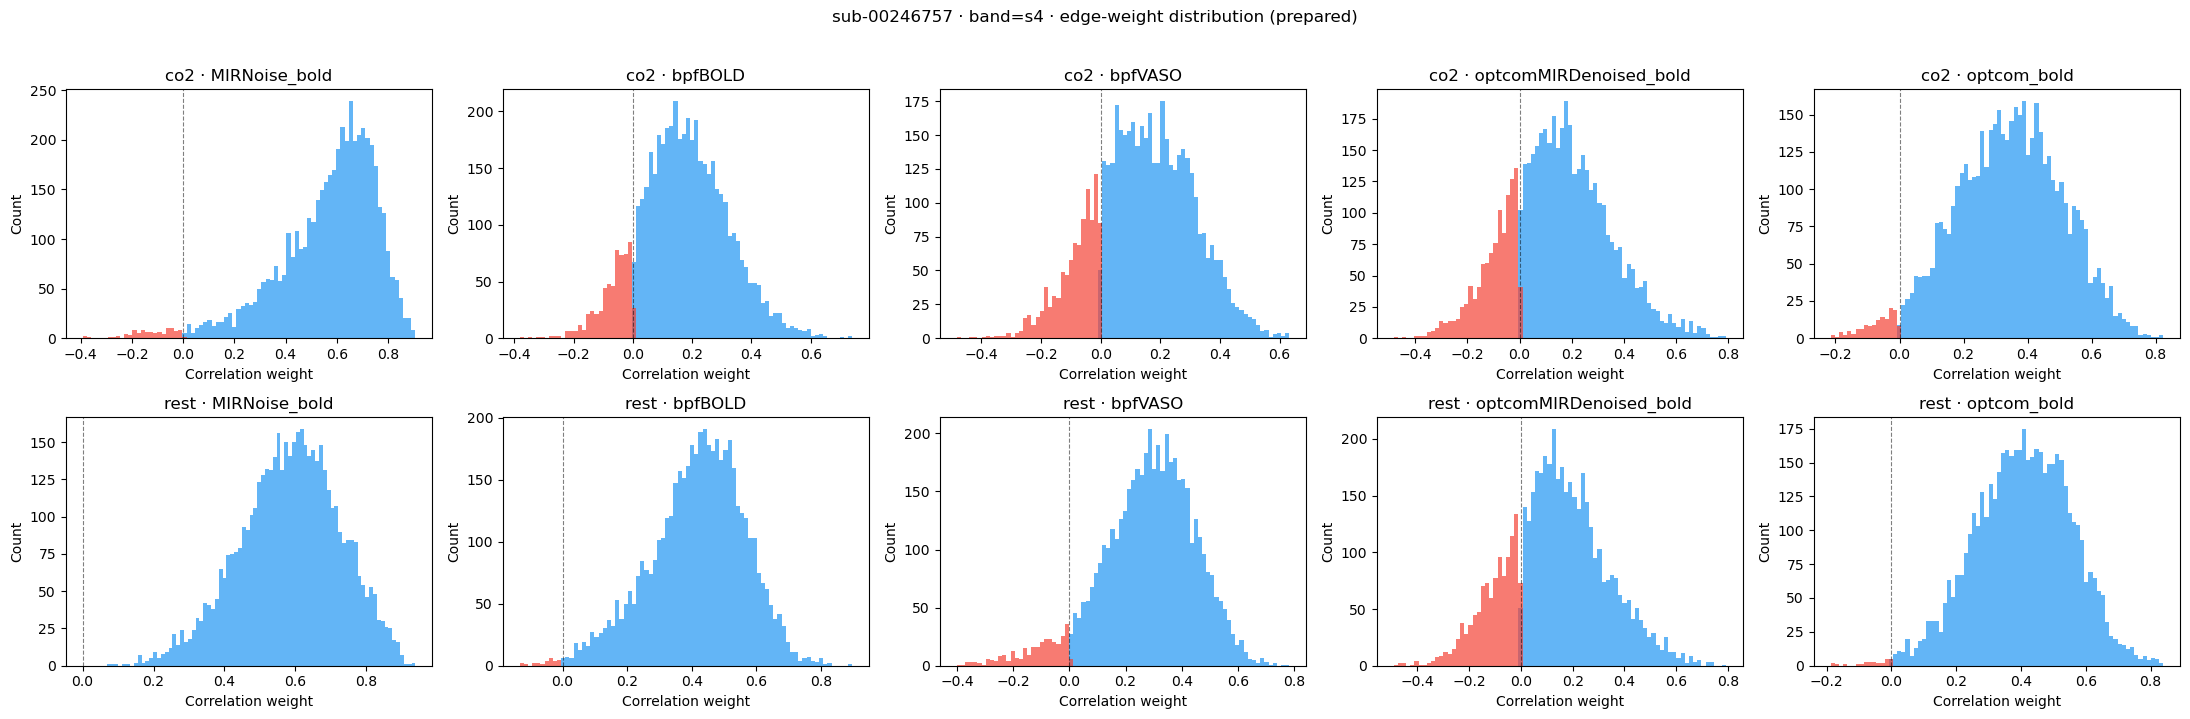

In [4]:
fig, axes = plt.subplots(*GRID, figsize=(22, 7), squeeze=False)
for ax, (_, rec) in zip(axes.ravel(), patient_data.items()):
    w = rec["corr"][np.triu_indices_from(rec["corr"], k=1)]
    plot_weight_distribution(
        {"positive_weights": w[w > 0], "negative_weights": w[w < 0]},
        ax=ax, title=rec["panel_title"], legend=False,
    )
fig.suptitle(f"{SUBJECT} \u00b7 band={BAND} \u00b7 edge-weight distribution (prepared)", y=1.02)
fig.tight_layout()
plt.show()

## 4. Prepared correlation matrices (before MP)

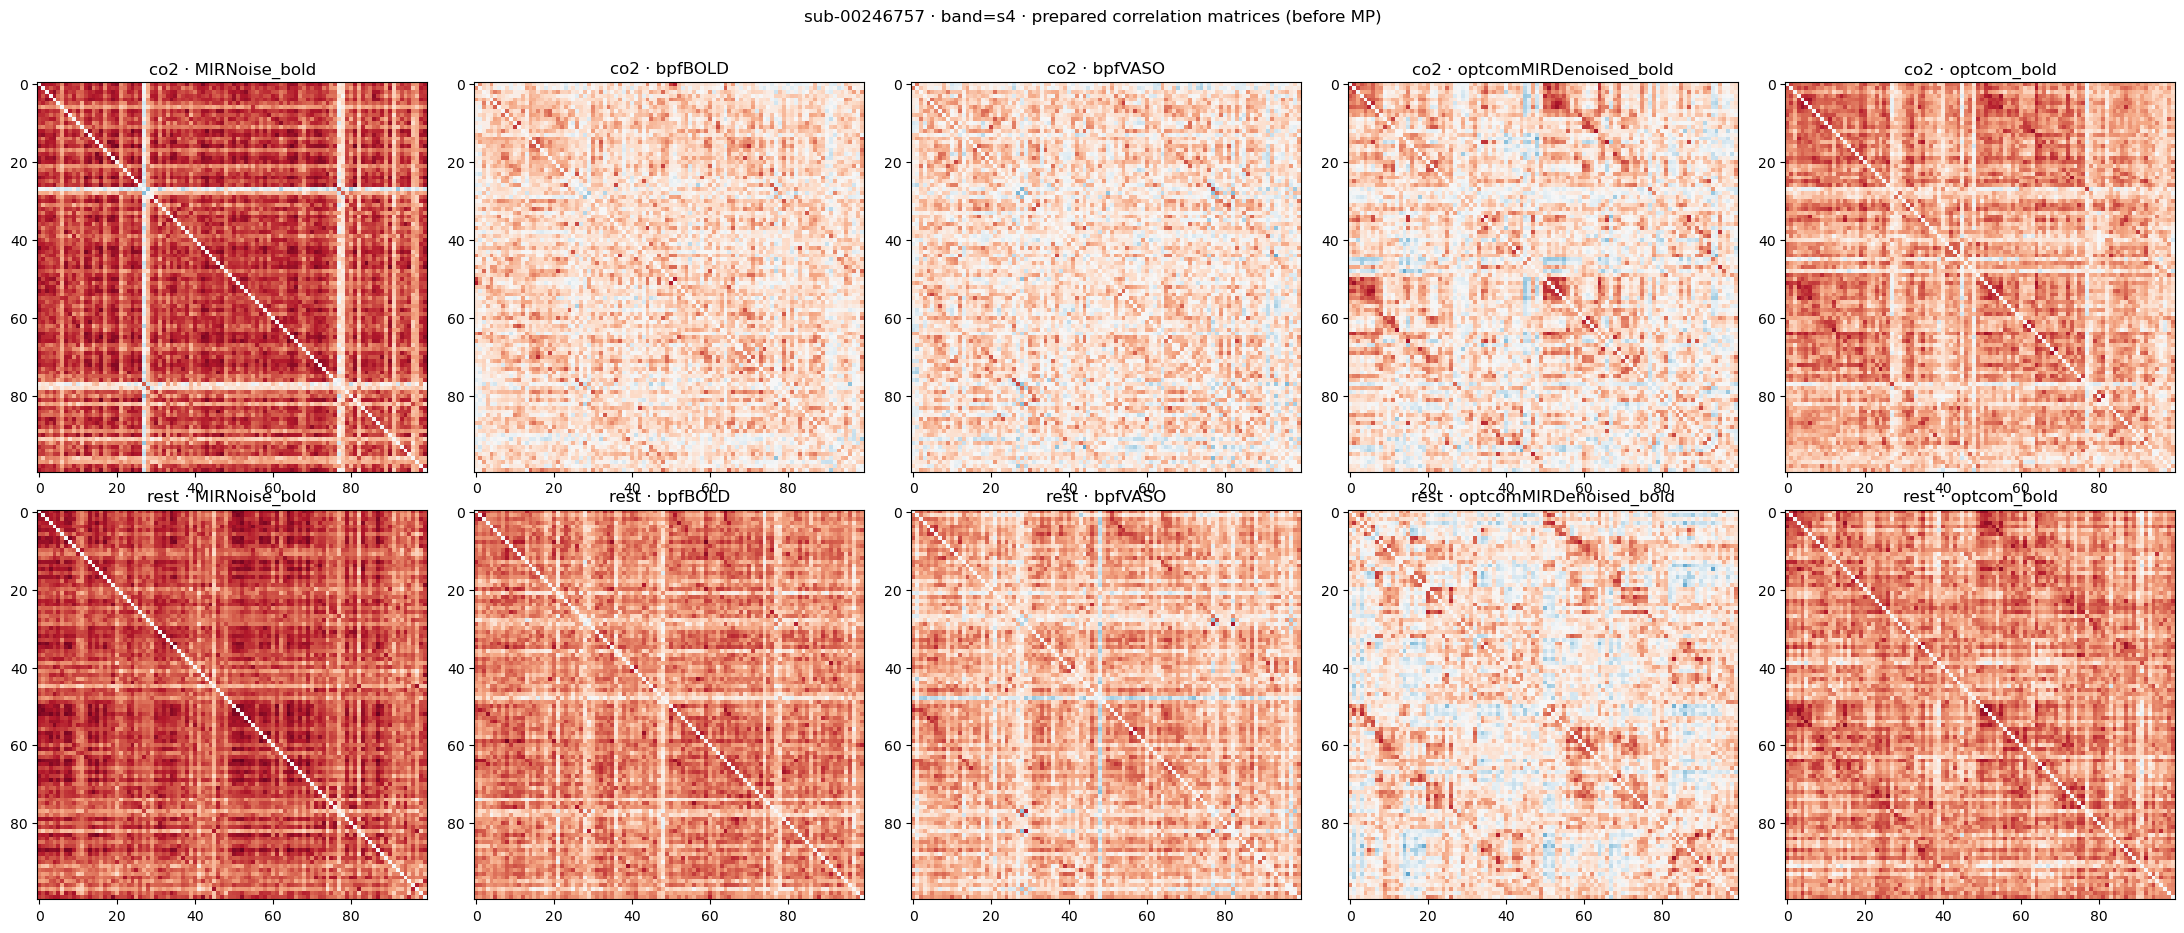

In [5]:
vmax_raw = float(max(np.abs(rec["corr"]).max() for rec in patient_data.values()))
fig, axes = plt.subplots(*GRID, figsize=(22, 9), squeeze=False)
for ax, (_, rec) in zip(axes.ravel(), patient_data.items()):
    plot_correlation_matrix(rec["corr"], ax=ax, title=rec["panel_title"], vmax=vmax_raw, colorbar=False)
fig.suptitle(f"{SUBJECT} \u00b7 band={BAND} \u00b7 prepared correlation matrices (before MP)", y=1.02)
fig.tight_layout()
plt.show()

## 5. Marchenko–Pastur denoising and re-plot

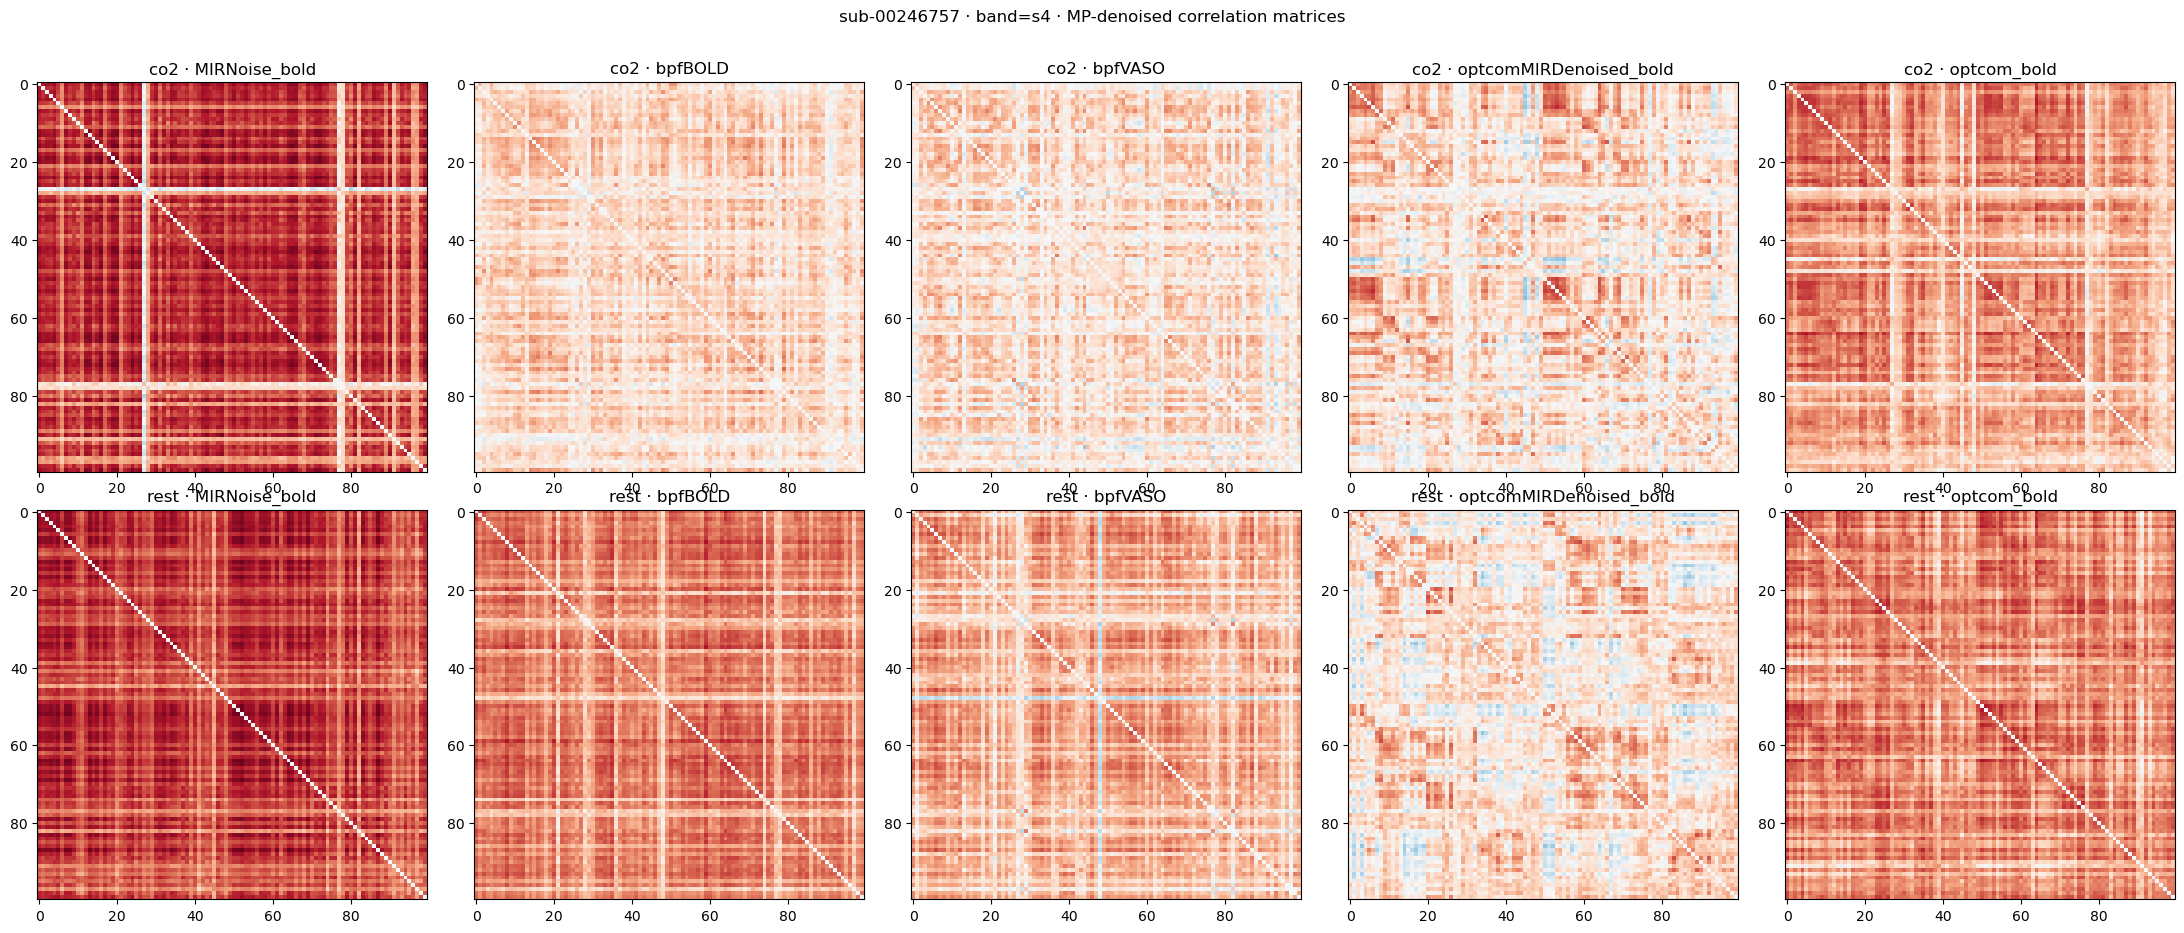

In [6]:
for rec in patient_data.values():
    rec["corr_mp"] = marchenko_pastur_denoise(rec["corr"], gamma=rec["gamma"])
vmax_mp = float(max(np.abs(rec["corr_mp"]).max() for rec in patient_data.values()))

fig, axes = plt.subplots(*GRID, figsize=(22, 9), squeeze=False)
for ax, (_, rec) in zip(axes.ravel(), patient_data.items()):
    plot_correlation_matrix(rec["corr_mp"], ax=ax, title=rec["panel_title"], vmax=vmax_mp, colorbar=False)
fig.suptitle(f"{SUBJECT} \u00b7 band={BAND} \u00b7 MP-denoised correlation matrices", y=1.02)
fig.tight_layout()
plt.show()

## 6. Percolation $P_\infty(\theta)$ and $E_\infty(\theta)$ on the MP-cleaned matrices

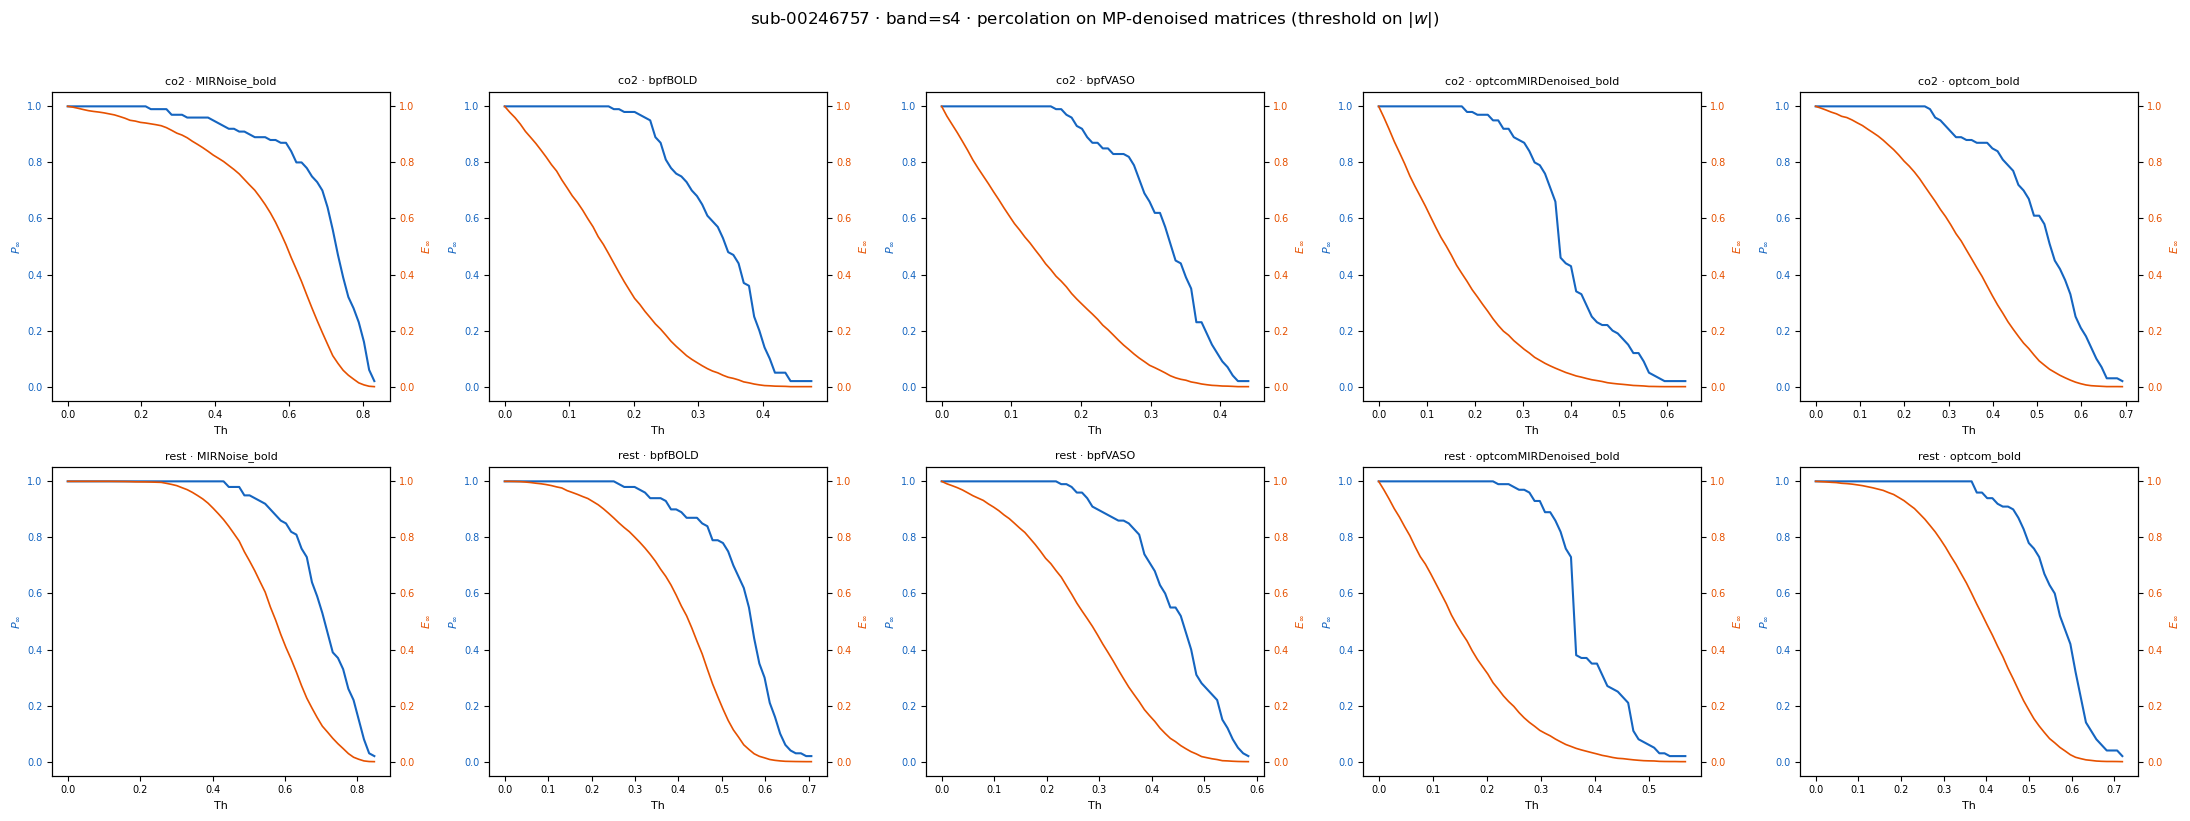

In [7]:
fig, axes = plt.subplots(*GRID, figsize=(22, 8), squeeze=False)
for ax, (_, rec) in zip(axes.ravel(), patient_data.items()):
    plot_percolation_curve(rec["corr_mp"], ax=ax, title=rec["panel_title"], n_thresholds=60, compact=True)
fig.suptitle(f"{SUBJECT} \u00b7 band={BAND} \u00b7 percolation on MP-denoised matrices (threshold on $|w|$)", y=1.02)
fig.tight_layout()
plt.show()

## 7. Network drawings — strongest connections (MP-cleaned)

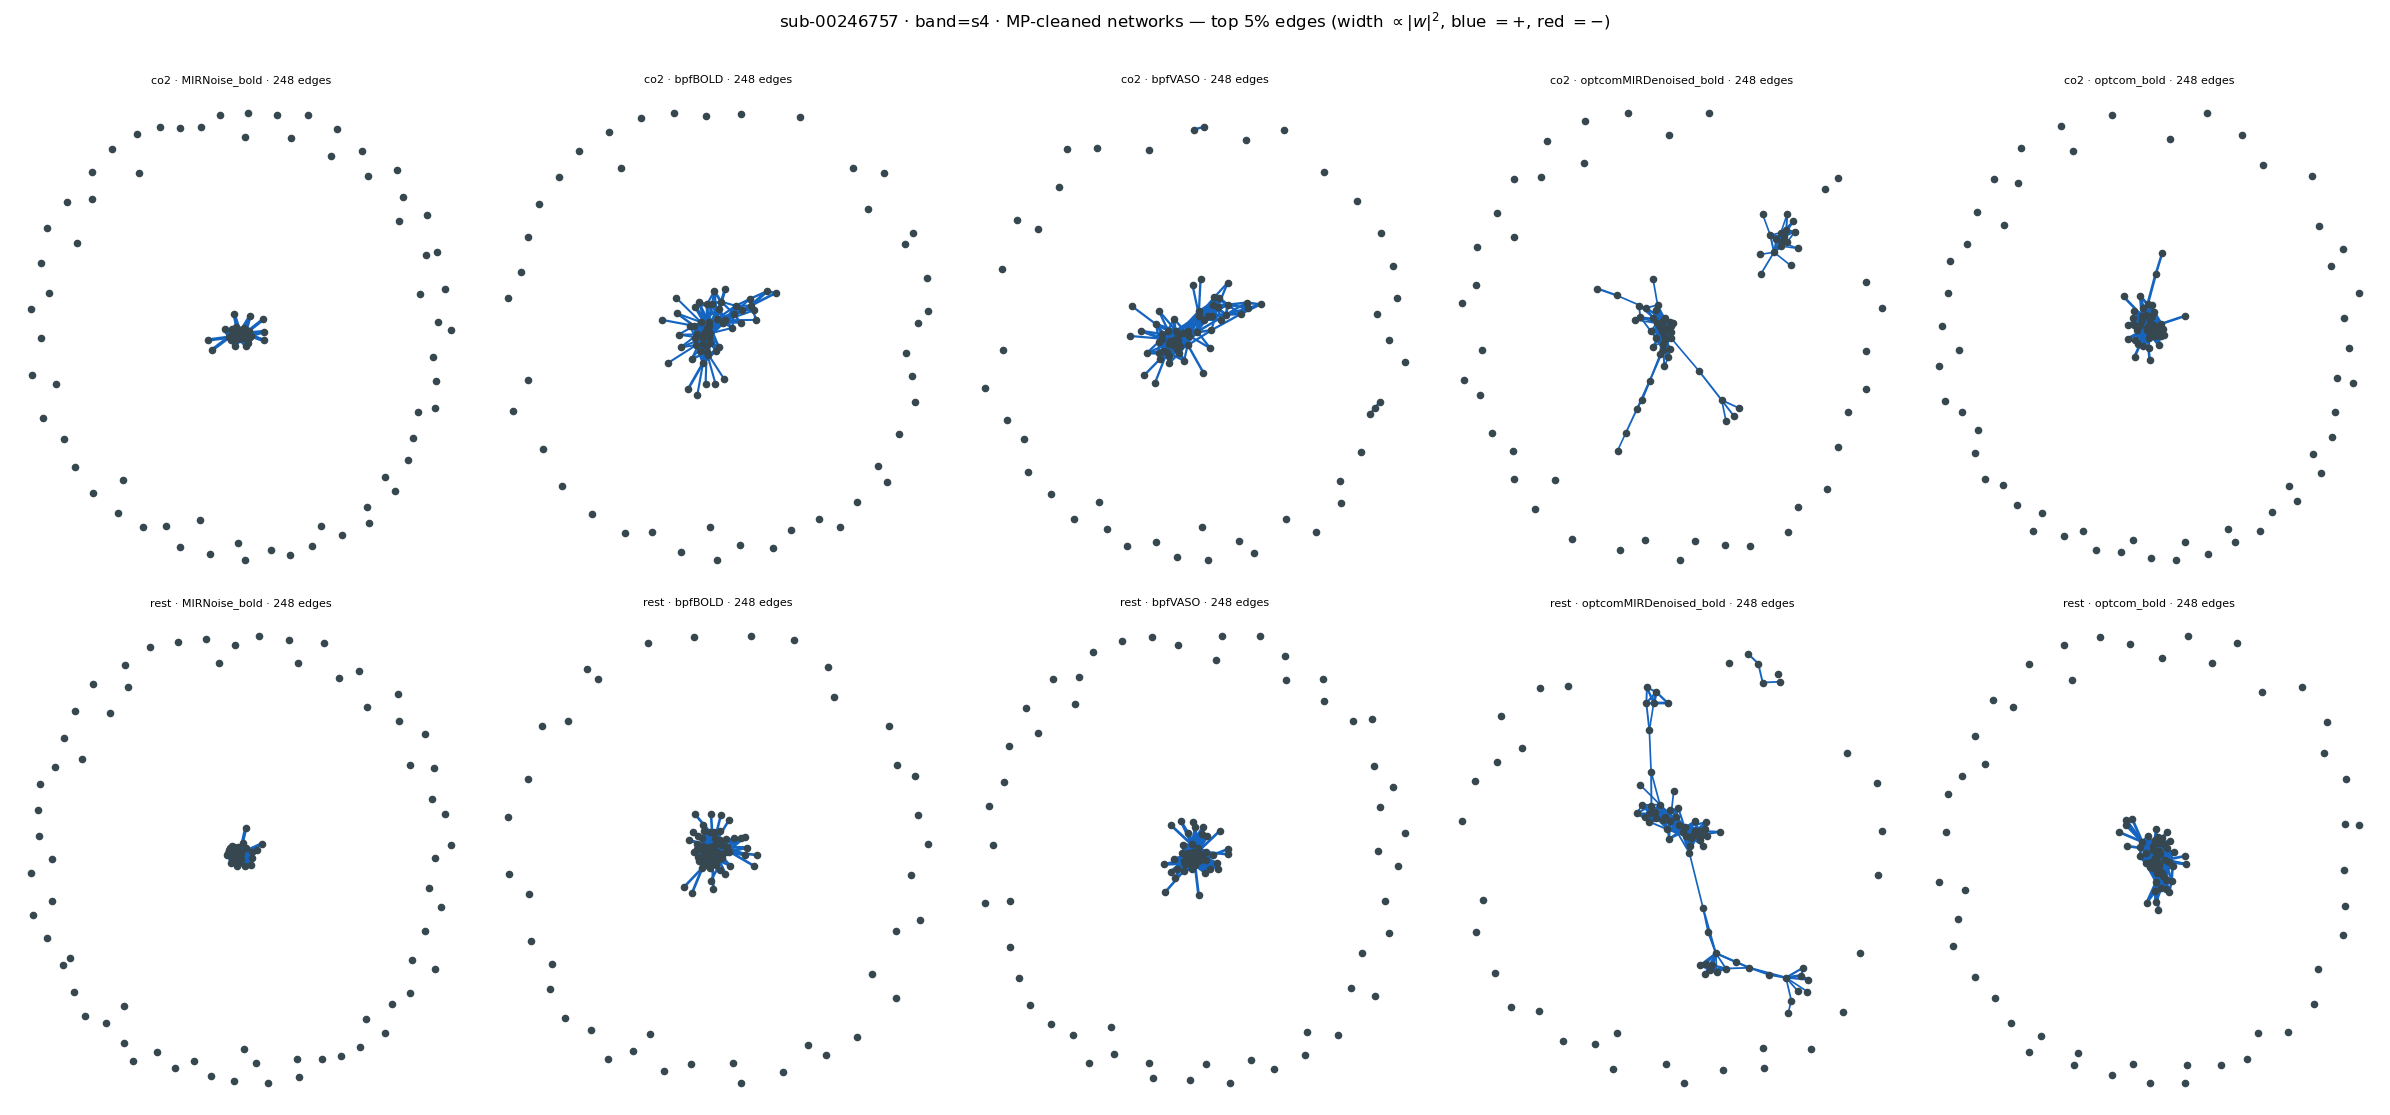

In [8]:
TOP_FRACTION = 0.05

fig, axes = plt.subplots(*GRID, figsize=(24, 11), squeeze=False)
for ax, (_, rec) in zip(axes.ravel(), patient_data.items()):
    C = rec["corr_mp"]
    thr = np.quantile(np.abs(C[np.triu_indices_from(C, k=1)]), 1 - TOP_FRACTION)
    G = nx.from_numpy_array(np.where(np.abs(C) >= thr, C, 0.0))
    w = np.array([d["weight"] for _, _, d in G.edges(data=True)])
    nx.draw(
        G, pos=nx.spring_layout(G, seed=0), ax=ax,
        node_size=20, node_color="#37474F",
        edge_color=np.where(w > 0, "#1565C0", "#C62828").tolist(),
        width=(np.abs(w) / np.abs(w).max()) ** 2 * 3.0,
    )
    ax.set_title(f"{rec['panel_title']} \u00b7 {G.number_of_edges()} edges", fontsize=8)
fig.suptitle(
    f"{SUBJECT} \u00b7 band={BAND} \u00b7 MP-cleaned networks — top {int(TOP_FRACTION*100)}% edges "
    "(width $\\propto |w|^2$, blue $=+$, red $=-$)",
    y=1.01,
)
fig.tight_layout()
plt.show()